In [1]:
import numpy as np
import pandas as pd

In [2]:
fear_greed=pd.read_csv("fear_greed_index.csv")
trades=pd.read_csv("historical_data.csv")

In [3]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'],dayfirst=True)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'],dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.floor('D')

In [9]:
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [10]:
fear_greed['date'].dtype

dtype('<M8[ns]')

In [11]:
merged = trades.merge(fear_greed[['date', 'classification']], on='date', how='left')

In [12]:
merged.shape

(211224, 18)

In [13]:
merged[['date', 'classification', 'Closed PnL']].head(10)

,date,classification,Closed PnL
0,2024-12-02,Extreme Greed,0.0
1,2024-12-02,Extreme Greed,0.0
2,2024-12-02,Extreme Greed,0.0
3,2024-12-02,Extreme Greed,0.0
4,2024-12-02,Extreme Greed,0.0
5,2024-12-02,Extreme Greed,0.0
6,2024-12-02,Extreme Greed,0.0
7,2024-12-02,Extreme Greed,0.0
8,2024-12-02,Extreme Greed,0.0
9,2024-12-02,Extreme Greed,0.0


In [14]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()
print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [15]:
merged['is_win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('classification')['is_win'].mean() * 100
print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_win, dtype: float64


In [16]:
volume = merged.groupby('classification')['Size USD'].sum()
print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


In [17]:
side_sentiment = merged.groupby(['classification', 'Direction'])['Closed PnL'].mean().unstack()
print(side_sentiment)

Direction       Auto-Deleveraging  Buy  Close Long  Close Short  \
classification                                                    
Extreme Fear                  NaN  0.0   81.197371   123.400238   
Extreme Greed                 NaN  0.0   61.830783    28.970490   
Fear                          NaN  0.0   83.000111   207.676658   
Greed                 7184.807003  0.0   88.958554    55.195496   
Neutral                       NaN  0.0   52.815787    94.796313   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                          NaN      1.331956        0.0   
Extreme Greed                         NaN    120.600968        0.0   
Fear                                  NaN      4.795642        0.0   
Greed                        -12752.91304     22.711911        0.0   
Neutral                               NaN     47.332193        0.0   

Direction       Open Short        Sell 

In [18]:
side_sentiment = merged.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack()
print(side_sentiment)

Side                  BUY        SELL
classification                       
Extreme Fear    34.114627   34.980106
Extreme Greed   10.498927  114.584643
Fear            63.927104   45.049641
Greed           25.002302   59.691091
Neutral         29.227429   39.456408


In [19]:
top_accounts = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_accounts)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


In [20]:
top_ids = top_accounts.index
top_behavior = merged[merged['Account'].isin(top_ids)].groupby('classification')['Closed PnL'].mean()
print(top_behavior)

classification
Extreme Fear      60.765008
Extreme Greed    136.960455
Fear              66.979192
Greed             93.526109
Neutral           53.831636
Name: Closed PnL, dtype: float64


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

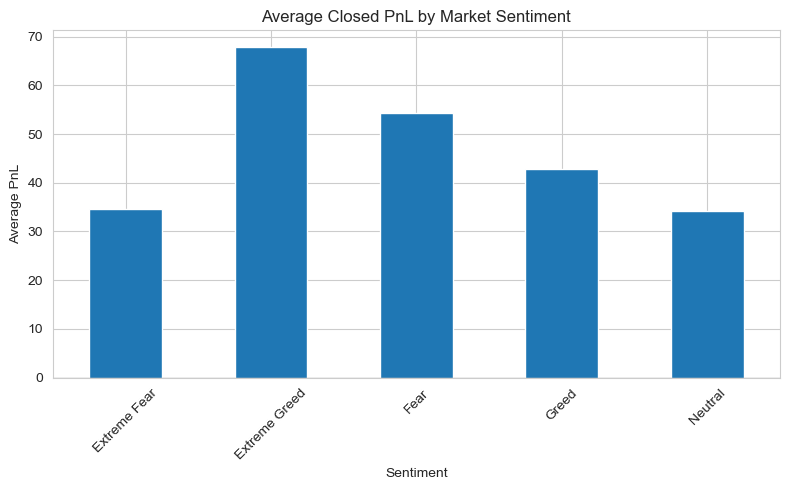

In [34]:
plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.xlabel('Sentiment')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

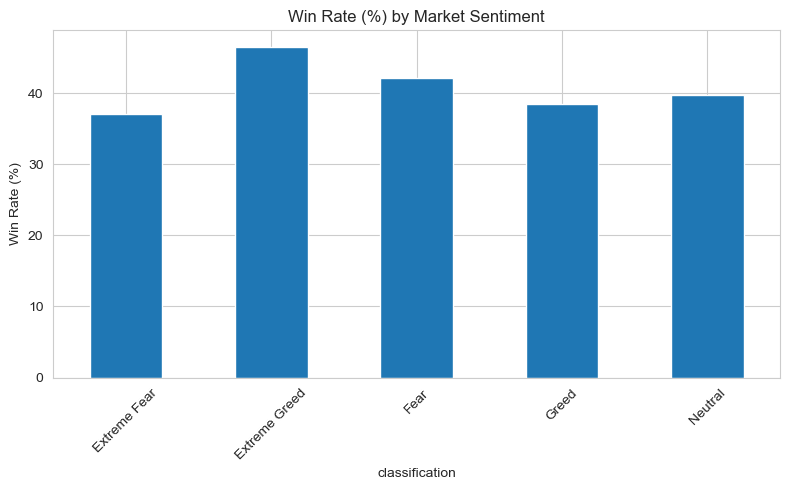

In [33]:
plt.figure(figsize=(8,5))
win_rate.plot(kind='bar')
plt.title('Win Rate (%) by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

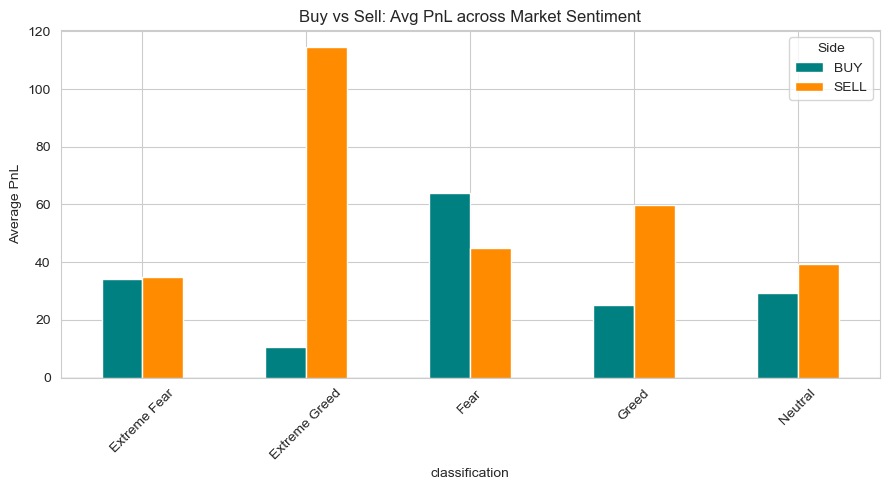

In [35]:
side_sentiment.plot(kind='bar',figsize=(9,5),color=['teal','darkorange'])
plt.title('Buy vs Sell: Avg PnL across Market Sentiment')
plt.ylabel('Average PnL')
plt.axhline(0, color='black',linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

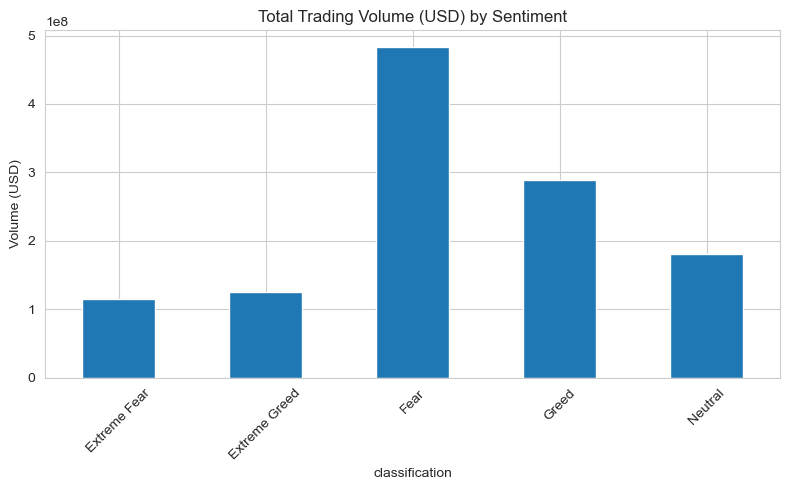

In [32]:
plt.figure(figsize=(8,5))
volume.plot(kind='bar')
plt.title('Total Trading Volume (USD) by Sentiment')
plt.ylabel('Volume (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

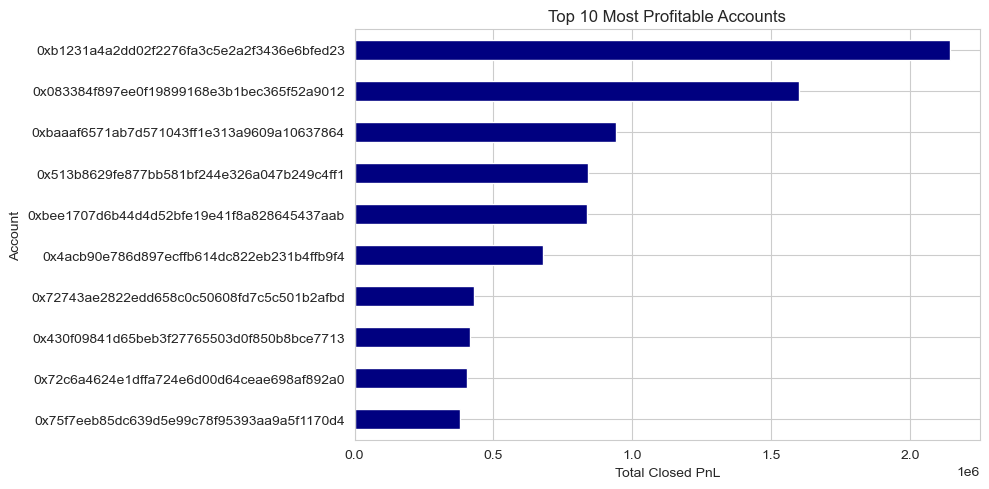

In [36]:
plt.figure(figsize=(10,5))
top_accounts.plot(kind='barh', color='navy')
plt.title('Top 10 Most Profitable Accounts')
plt.xlabel('Total Closed PnL')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()